Note: to run this notebook, please use the the psiresp package:
```bash
conda install -c conda-forge psiresp ipykernel
```
It is much to install and run with Python 3.9 on a Linux system (or WSL)

In [ ]:
# Documentation build
try:
    import os, sys
    sys.path.insert(1, os.path.abspath('/home/runner/work/psi4/psi4/code/objdir/stage//usr/local/psi4/lib/'))
except ImportError:
    pass

import psi4

/home/teaching/miniconda3/envs/psi4-test/lib/python3.9/site-packages/psi4/driver/procrouting/solvent/ddx.py:31: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import parse_version


### Let's do a basic ESP calculation on a 3D rectangular grid

In [2]:
import os
import psi4
import psi4.core as p4c
import numpy as np

In [3]:
with open("psi4.txt", "r") as f:
    mol_psi4 = f.read()

In [4]:

# make a local scratch folder on your C: drive
scratch = r"C:\Psi4Scratch"
os.makedirs(scratch, exist_ok=True)

# set environment variable for this session
os.environ["PSI_SCRATCH"] = scratch

# optional: also set common temp vars so other I/O uses the same drive
os.environ["TMP"] = scratch
os.environ["TEMP"] = scratch

print("PSI_SCRATCH ->", os.environ["PSI_SCRATCH"])

psi4.set_output_file("output.dat", False)
psi4.set_options({"REFERENCE": "UHF"})
psi4.set_options({
    # allow more SCF iterations
    "scf__maxiter": 500,

    # initial guess: try 'SAD' (or 'HUCKEL', 'CORE'); AUTO is default
    "scf__guess": "SAD",

    # try a small-basis pre-SCF and project into full basis
    "scf__basis_guess": True,    # runs a small-basis SCF first

    # DIIS settings (default diis=True); adjust diis_start if needed
    "scf__diis": True,
    "scf__diis_start": 2,        # start collecting DIIS vectors early

    # damping to avoid oscillations: percent (0..100). Try 10-30 for hard cases
    "scf__damping_percentage": 20.0,

    # if you want Psi4 to *not* raise on maxiter but return the last wfn:
    "scf__fail_on_maxiter": False,

    # convergence criteria:
    "scf__d_convergence": 1e-6,  # density conv 
    "scf__e_convergence": 1e-8,  # energy conv
})

PSI_SCRATCH -> C:\Psi4Scratch


In [5]:
# User params 
numpoints_per_dim = 25
spacing = 0.20            # A per voxel
padding = 3.0             # Extra margin if molecule is large 

# Molecule of interest
geom = psi4.geometry(mol_psi4)

# Set up the wavefunction
ene, wfn = psi4.energy('scf/STO-3G', return_wfn = True)

# Initialise the ESP calculator object
myepc = p4c.ESPPropCalc(wfn)

# Number of points to evaluate the ESP on per dimension (reference values below were generated with 5)
numpoints_per_dim = 25

# Get atomic coordinates in Bohr -> convert to Angstrom
BOHR_TO_ANG = 0.529177210903
nat = wfn.molecule().natom()
coords_bohr = np.array([[wfn.molecule().x(i),
                         wfn.molecule().y(i),
                         wfn.molecule().z(i)] for i in range(nat)])
coords_ang = coords_bohr * BOHR_TO_ANG

# Molecular bounding box (Å)
min_xyz = coords_ang.min(axis=0)
max_xyz = coords_ang.max(axis=0)
extent = max_xyz - min_xyz   # box dimensions in x,y,z (Å)

# Half-span requested by the user (Å)
half_span_user = spacing * (numpoints_per_dim - 1) / 2.0

# Required half-span to contain molecule + padding
required_half_span = 0.5 * extent + padding

# Choose final half-span 
half_span = np.maximum(half_span_user, required_half_span.max())

# Compute origin centered on molecular centroid as before
centroid_ang = coords_ang.mean(axis=0)
origin = centroid_ang - np.array([half_span, half_span, half_span])

# Keep spacing fixed, but adjust numpoints_per_dim to exactly cover the new box:
npoints_needed = int(np.ceil((2.0 * half_span) / spacing)) + 1
# keep at least 3 points to avoid degenerate grids
numpoints_per_dim = max(3, npoints_needed)

# Setup the points array
points = []
for ix in range(numpoints_per_dim):
    x = origin[0] + ix * spacing
    for iy in range(numpoints_per_dim):
        y = origin[1] + iy * spacing
        for iz in range(numpoints_per_dim):
            z = origin[2] + iz * spacing
            points.append([float(x), float(y), float(z)])
points = np.array(points, dtype=float)
psi4_matrix = p4c.Matrix.from_array(points)

# Calculate the ESPs 
psi4.set_num_threads(14, quiet = True)
esps = np.array(myepc.compute_esp_over_grid_in_memory(psi4_matrix))

In [6]:
psi4.set_options({'reference': 'rhf'})
psi4.optimize('scf/cc-pvdz', molecule=h2o)

NameError: name 'h2o' is not defined

In [7]:
import numpy as np
# Reshape the output to follow C-order (this makes it easier to visualize)
n = numpoints_per_dim
esp_grid = esps.reshape((n, n, n,))

# Save the output for use later
np.savez_compressed(
    "esp_data.npz",
    esp=esp_grid,
    origin=origin,
    spacing=spacing,
    shape=esp_grid.shape,
    points=points
    
)



In [8]:
data = np.load("esp_data.npz")
esp_grid = data["esp"]
origin = data["origin"]
spacing = data["spacing"]

### The results can be visualised with the help of PyVista

In [11]:
import pyvista as pv

# Create a uniform grid
grid = pv.ImageData()
grid.dimensions = esp_grid.shape
grid.origin = tuple(origin.tolist()) ## origin in Angstrom
grid.spacing = (spacing, spacing, spacing)
grid.point_data["ESP"] = esp_grid.flatten(order="C")

# Create isosurfaces at percentiles 5, 50 and 95
flat = esp_grid.flatten()
p_low, p_mid, p_high = np.percentile(flat, [5, 50, 95])
levels = [p_low, p_mid, p_high]
print("Percentile levels, A: ", levels)

contours = grid.contour(isosurfaces=levels, scalars="ESP")

p = pv.Plotter()
p.add_mesh(contours, opacity=0.6, cmap="coolwarm")
p.add_axes()
p.show_grid()
p.camera.zoom(0.5) 
p.show()

Percentile levels, A:  [np.float64(-0.048466918151019105), np.float64(-0.0009582585343017591), np.float64(0.0763234681567769)]


Widget(value='<iframe src="http://localhost:52173/index.html?ui=P_0x1380a6a3d40_2&reconnect=auto" class="pyvis…

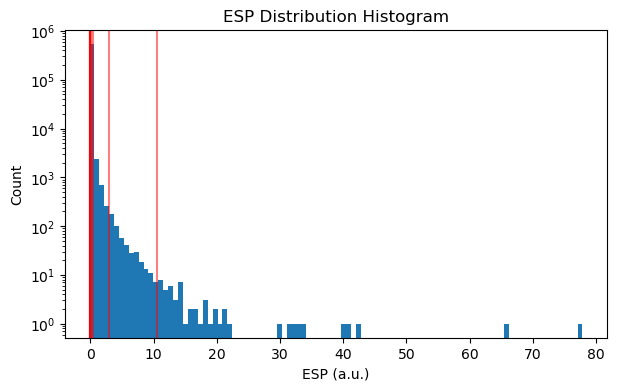

In [12]:
import matplotlib.pyplot as plt
flat = esp_grid.flatten()

plt.figure(figsize=(7,4))
plt.hist(flat, bins=100, color='C0')
plt.xlabel("ESP (a.u.)")
plt.ylabel("Count")
plt.yscale("log") # log scale on the y axis to deal with most of the box being empty space
plt.title("ESP Distribution Histogram")
p = np.percentile(flat, [1, 5, 25, 50, 75, 95, 99, 99.9, 99.99])
for v in p:
    plt.axvline(v, color='r', alpha=0.5)
plt.show()

### Trialing the use of psiresp to generate the RESP charges (to be used as the one of the outputs of the VAE/)

In [9]:
import psiresp
dmso = psiresp.Molecule.from_smiles("CS(=O)C")
# Create job
job = psiresp.Job(molecules=[psiresp_mol])
print(f"Created job in: {job.working_directory}")

# Run to generate inputs
try:
    job.run(client=None)
except SystemExit:
    print(f"\nQM inputs generated")
    print(f"  Run the script in: {job.working_directory / 'single_point'}")
    print(f"\nAfter running QM calculations, re-run:")
    print(f"  job.run(client=None)")
    print(f"  charges = job.charges[0]")

Created job in: psiresp_working_directory


generating-orientations: 100%|██████████| 1/1 [00:00<00:00, 51.82it/s]


QM inputs generated
  Run the script in: psiresp_working_directory/single_point

After running QM calculations, re-run:
  job.run(client=None)
  charges = job.charges[0]


In [12]:
job.run(client=None)   
print(job.charges[0])  # numpy array of atom charges for the first molecule


compute-esp: 100%|██████████| 1/1 [00:00<00:00,  1.91it/s]


[-0.0937114493002538 -2.7023806025336357  1.1228144393460529
  1.1433732056898898 -0.8358484546928552  0.0738036222992136
 -0.7365189661725693  0.4418677185388477  0.1975290620464795
  0.0912331873256867 -0.2294906570839014  0.16062065280632
  0.1303994692136701  0.3245954973018734 -0.0516835081956492
  0.110473529942719  -0.3756652640078449  0.4438645596470376
  1.1368445157062321  0.1109401227271978 -0.0531500345655429
 -0.212617266955842   0.2193435626467939 -1.470292745565571
  0.7269397633808737  0.7269397633808737 -0.7874906501409256
  0.6602365077666943  0.6602365077666943 -0.2878326972241833
  0.4089434801763971 -0.376114513894709   0.4078776010629775
 -2.2255847935796225  0.971280895357588   0.971280895357588
  0.971280895357588  -5.066602434565507   1.418754124682132
  1.4965276827472342  1.3769827762039584]


In [7]:
sum(job.charges[0])

-5.273559366969494e-16

Testing psiresp on a test molecule from the CSD

In [ ]:
from rdkit import Chem
from rdkit.Chem import AllChem
from rdkit import RDLogger

def neutralize_atoms(mol):
    pattern = Chem.MolFromSmarts("[+1!h0!$([*]~[-1,-2,-3,-4]),-1!$([*]~[+1,+2,+3,+4])]")
    at_matches = mol.GetSubstructMatches(pattern)
    at_matches_list = [y[0] for y in at_matches]
    if len(at_matches_list) > 0:
        print("Detected matches")
        for at_idx in at_matches_list:
            atom = mol.GetAtomWithIdx(at_idx)
            chg = atom.GetFormalCharge()
            hcount = atom.GetTotalNumHs()
            atom.SetFormalCharge(0)
            atom.SetNumExplicitHs(hcount - chg)
            atom.UpdatePropertyCache()
    return mol

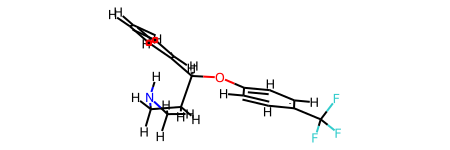

In [46]:
# Load the molecule
path = "csd_mol.sdf"
suppl = Chem.SDMolSupplier(path, removeHs=False)
mol = next(iter(suppl), None)

mol

In [47]:
smiles = Chem.MolToSmiles(mol)
print(smiles)  # Output: Cc1ccccc1

[H]c1c([H])c([H])c([C@@]([H])(Oc2c([H])c([H])c(C(F)(F)F)c([H])c2[H])C([H])([H])C([H])([H])N([H])C([H])([H])[H])c([H])c1[H]


In [51]:
import psiresp

"""
# Load the molecule
path = "csd_mol.sdf"
suppl = Chem.SDMolSupplier(path, removeHs=False)
mol = next(iter(suppl), None)
print(f"Loaded a molecule with: {mol.GetNumAtoms()} atoms")

# Neutralise the molecule
mol = neutralize_atoms(mol)
print(f"Following neutralisation: {mol.GetNumAtoms()} atoms")
"""

# Verify molecule has conformers
if mol.GetNumConformers() == 0:
    print("No conformer found, embedding...")
    AllChem.EmbedMolecule(mol, randomSeed=42)
    AllChem.MMFFOptimizeMolecule(mol)
else:
    print(f"Found {mol.GetNumConformers()} conformer(s)")

# Create psiresp Molecule 
try:
    psiresp_mol = psiresp.Molecule.from_rdkit(mol)
    print("Successfully created psiresp Molecule")
except Exception as e:
    raise ValueError(f"Error creating psiresp molecule: {e}")

# Create job
job = psiresp.Job(molecules=[psiresp_mol])
print(f"Created job in: {job.working_directory}")

# Run to generate inputs
try:
    job.run(client=None)
except SystemExit:
    print(f"\nQM inputs generated")
    print(f"  Run the script in: {job.working_directory / 'single_point'}")
    print(f"\nAfter running QM calculations, re-run:")
    print(f"  job.run(client=None)")
    print(f"  charges = job.charges[0]")

Found 1 conformer(s)
Successfully created psiresp Molecule
Created job in: psiresp_working_directory


generating-orientations: 100%|██████████| 1/1 [00:00<00:00, 70.94it/s]


QM inputs generated
  Run the script in: psiresp_working_directory/single_point

After running QM calculations, re-run:
  job.run(client=None)
  charges = job.charges[0]


Let's verify the overall estimated charge for the molecule is neutral

In [52]:
job.run(client=None)   
print(job.charges[0])  # numpy array of atom charges for the first molecule

compute-esp: 100%|██████████| 1/1 [00:00<00:00,  4.01it/s]


[-0.3304679521787277 -0.0358678079188456 -0.1442257517466099
  0.2285565734887312  0.0586682434373685 -0.0264170273286043
 -0.0837763695657814 -0.1230457889803089  0.1304131565477271
 -0.1940540966668532  0.2329050026107839 -0.119552504617812
 -0.0746443946518365 -0.1000633731762596 -0.0049090544087934
 -0.1147671245885875 -0.1685660858751479 -0.2306175622603055
 -1.2551235641718237  1.964700399196359   0.0074987328705483
 -0.4339798386658052  0.2751566748722292  0.0993989211143413
  0.0615391021021094 -0.2150075503226345  0.1336200130230081
  0.0071810434027228  0.0564882354510841  0.349043663442311
  0.0137196565640887  0.0137196565640887  0.2676227991912004
  0.2676227991912004  0.4481288505884815 -0.4561384072638367
 -0.4561384072638367 -0.4561384072638367  0.1550644037713899
  0.2524531414864733]


In [53]:
sum(job.charges[0])

-3.885780586188048e-16